In [83]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def display(img, cmap='gray'):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

In [18]:
reeses = cv.imread('../data/reeses_puffs.png', 0)
cereal = cv.imread('../data/many_cereals.jpg', 0)

In [23]:
# BRUTE FORCE DETECTION (ORB)
orb = cv.ORB_create() # detector

In [26]:
# find keypoint and description - detects and computes features
pt1, ds1 = orb.detectAndCompute(reeses, None)
pt2, ds2 = orb.detectAndCompute(cereal, None)

In [27]:
# matching object
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

In [30]:
matches = bf.match(ds1, ds2)

In [32]:
# sort in order of distance via lambda expression
matches = sorted(matches, key=lambda x:x.distance)

In [33]:
single_match = matches[0] # less distance == better match
single_match.distance

42.0

In [52]:
# sort in order of distance via lambda expression
matches = sorted(matches, key=lambda x:x.distance)
len(matches)

138

In [53]:
reeses_matches = cv.drawMatches(reeses, pt1, cereal, pt2, matches[:20], None, flags=2)
len(reeses_matches)

560

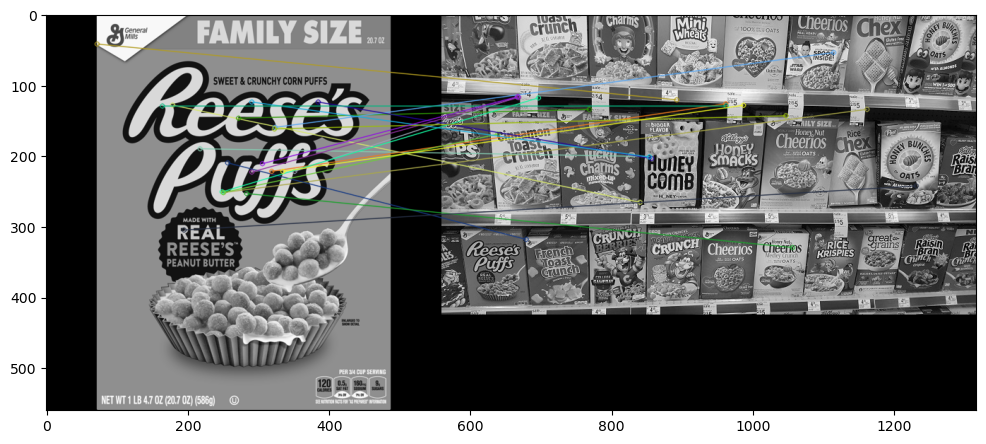

In [51]:
display(reeses_matches)

In [54]:
# Matching using SIFT
sift = cv.SIFT_create()

In [57]:
kp1, ds1 = sift.detectAndCompute(reeses, None)
kp2, ds2 = sift.detectAndCompute(cereal, None)

In [60]:
ds1.shape

(1502, 128)

In [56]:
bf = cv.BFMatcher()

In [66]:
matches = bf.knnMatch(ds1, ds2, k=2)

In [68]:
good = []

# less distance == better match
for match1, match2 in matches:
    # if match1 distance is less than 75% of match2 distance
    # then descriptor is a good match to keep
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [72]:
good
len(good)

78

In [73]:
matches
len(matches)

1502

In [78]:
sift_matches = cv.drawMatchesKnn(reeses, kp1, cereal, kp2, good, None, flags=2)

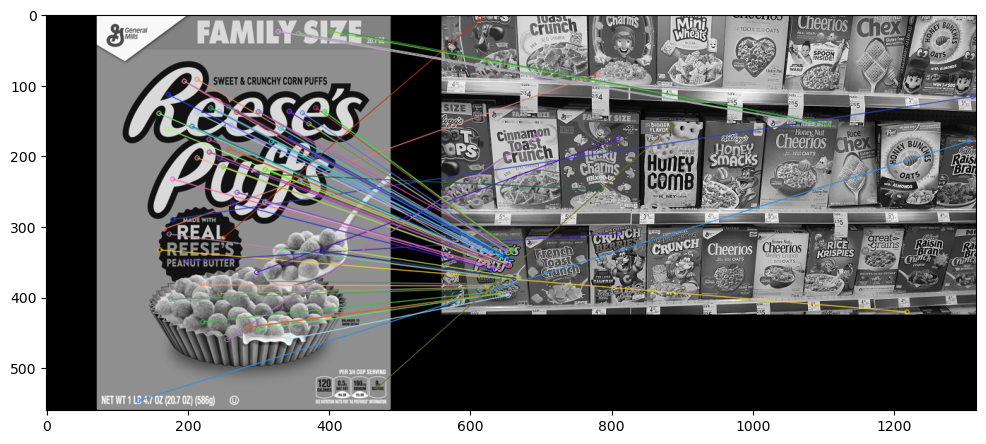

In [79]:
display(sift_matches)

In [85]:
sift = cv.SIFT_create()

In [86]:
kp1, ds1 = sift.detectAndCompute(reeses, None)
kp2, ds2 = sift.detectAndCompute(cereal, None)

In [110]:
# FLANN = better than BF (brute force) but only finds approx nearest neighbors
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = {'checks': 50} # == dict(checks=50) 

In [111]:
flann = cv.FlannBasedMatcher(indexParams=index_params, searchParams=search_params)

In [112]:
matches = flann.knnMatch(ds1, ds2, k=2)

In [113]:
matchesMask = [[0,0] for i in range(len(matches))]
#matchesMask

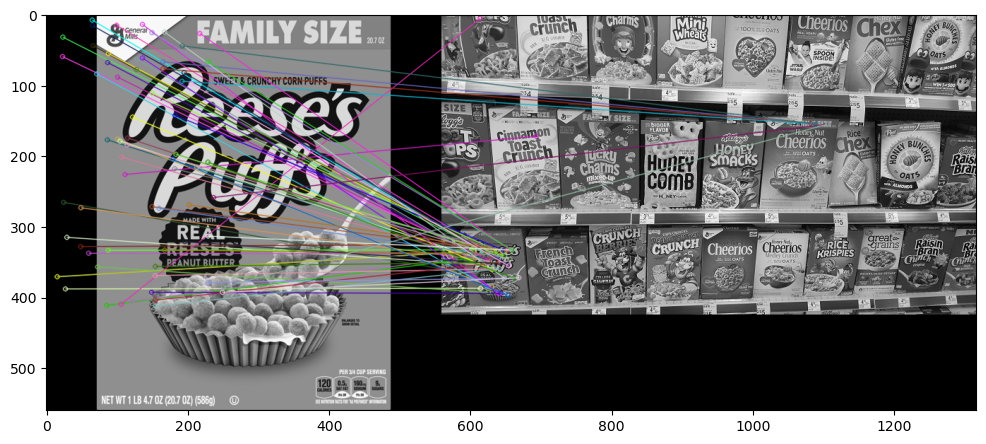

In [ ]:
flann_matches = cv.drawMatchesKnn(reeses, kp2, cereal, kp2, good, None, flags=2)
display(flann_matches)

In [109]:
sift = cv.SIFT_create()
kp1, ds1 = sift.detectAndCompute(reeses, None)
kp2, ds2 = sift.detectAndCompute(cereal, None)


In [115]:
good = []

for i, (match1, match2) in enumerate(matches):
    if match1.distance < 0.7*match2.distance:
        matchesMask[1] = [1,0]


In [121]:
draw_params = dict(matchColor=(0,255,0), singlePointColor=(255,0,0), matchesMask=matchesMask, flags=2)

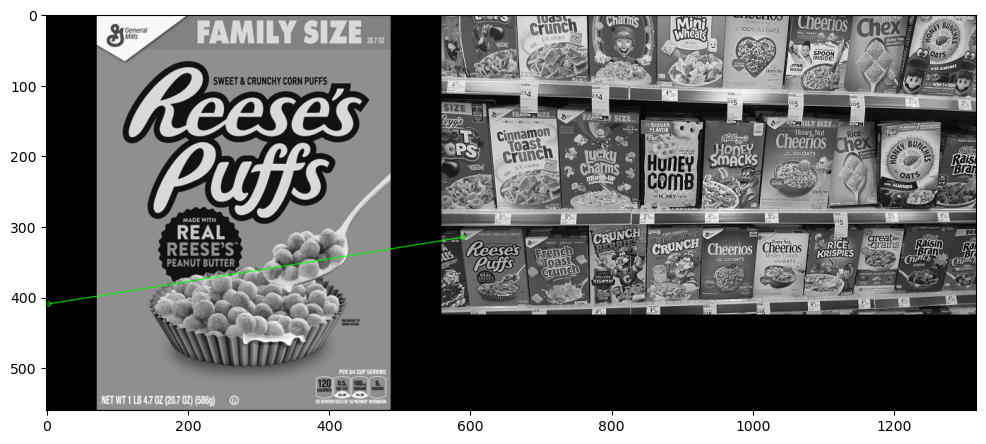

In [122]:
flann_matches = cv.drawMatchesKnn(reeses, kp2, cereal, kp2, matches, None, **draw_params)
display(flann_matches)